In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Students Social Media Addiction.csv to Students Social Media Addiction.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Students Social Media Addiction.csv")

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


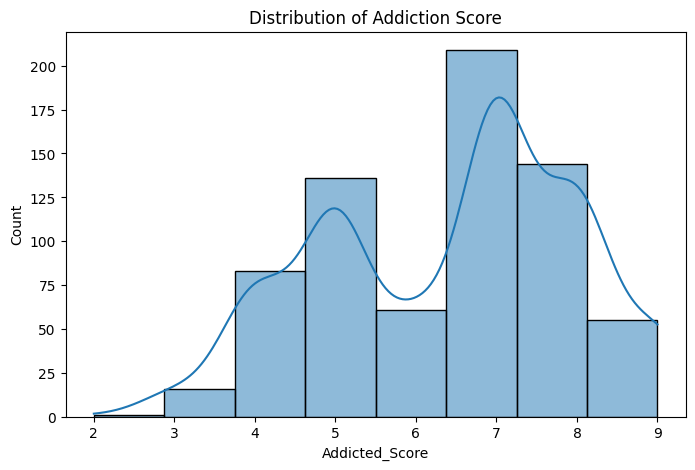

In [ ]:
## Target Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Addicted_Score'], bins=8, kde=True)

plt.title("Distribution of Addiction Score")
plt.show()

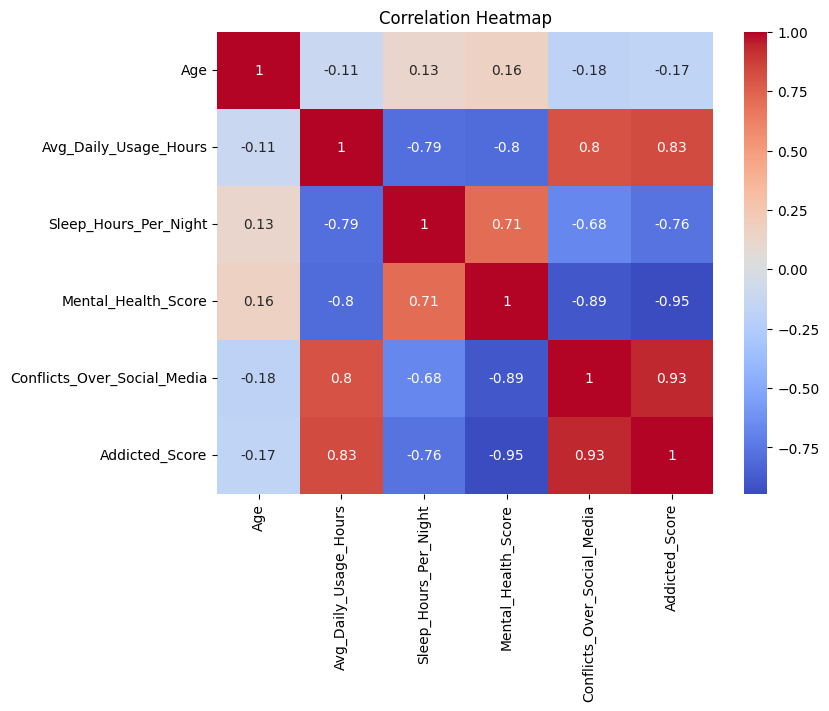

In [ ]:
## Correlation Heatmap
numeric_cols = [
    'Age',
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media',
    'Addicted_Score'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Key Insights

1. Average daily usage hours showed a strong positive correlation (0.83) with addiction score.

2. Sleep hours showed a strong negative correlation (-0.76), suggesting higher social media addiction is associated with reduced sleep.

3. Mental health score exhibited the strongest negative relationship (-0.95) with addiction severity.

4. Conflicts arising from social media usage had a strong positive correlation (0.93) with addiction score.

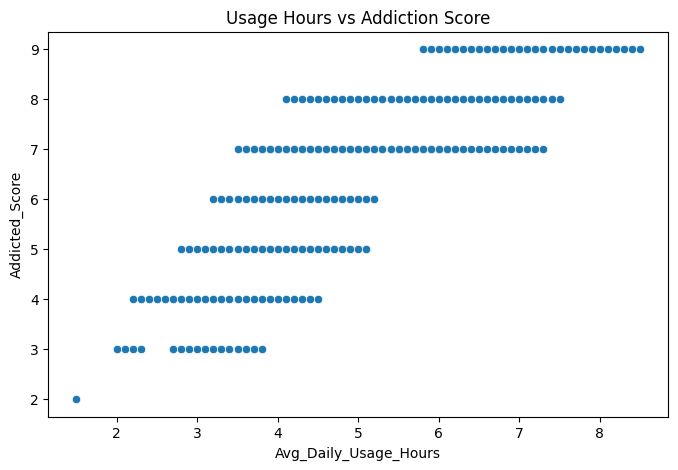

In [ ]:
## Usage Hours vs Addiction

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Addicted_Score'
)

plt.title("Usage Hours vs Addiction Score")
plt.show()

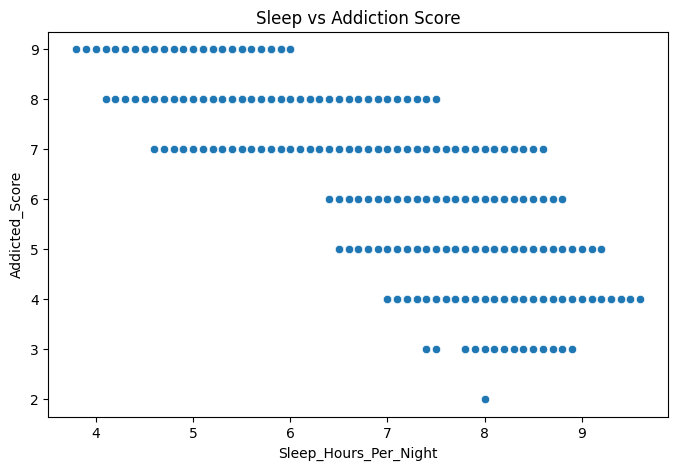

In [ ]:
## Sleep vs Addiction
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Sleep_Hours_Per_Night',
    y='Addicted_Score'
)

plt.title("Sleep vs Addiction Score")
plt.show()

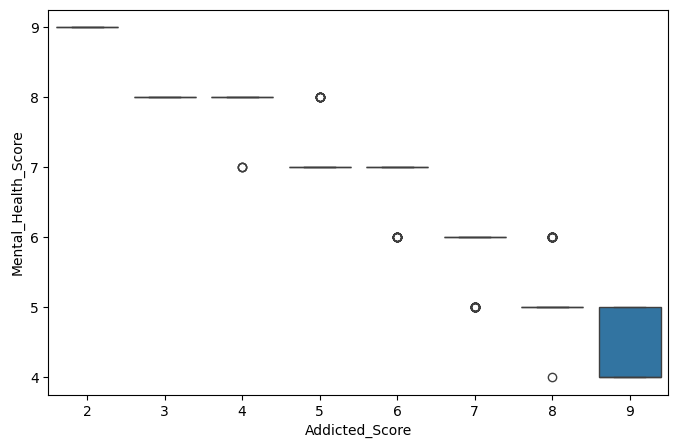

In [ ]:
## Mental Health vs Addiction
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Addicted_Score',
    y='Mental_Health_Score',
    data=df
)

plt.show()

In [ ]:
df['Risk_Score'] = (
    0.35*(df['Addicted_Score']/9)
    + 0.25*(df['Avg_Daily_Usage_Hours']/8.5)
    + 0.20*(df['Conflicts_Over_Social_Media']/5)
    + 0.10*(1-df['Sleep_Hours_Per_Night']/10)
    + 0.10*(1-df['Mental_Health_Score']/10)
)

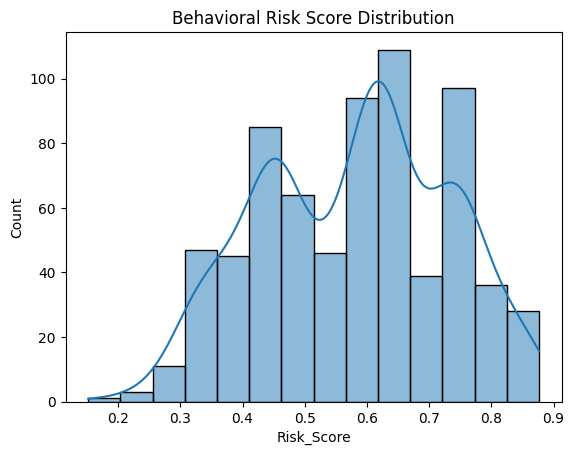

In [ ]:
sns.histplot(df['Risk_Score'], kde=True)
plt.title("Behavioral Risk Score Distribution")
plt.show()
